In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('mymoviedb (1).csv', lineterminator = '\n')

In [3]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [46]:
#Need to change the Release_Date Datatype str to date/datetime format

In [11]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [13]:
#white space between 

In [15]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9822    False
9823    False
9824    False
9825    False
9826    False
Length: 9827, dtype: bool

In [17]:
df.duplicated().sum()

0

In [19]:
df.describe() #statistical operation

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


# Data Preprocessing

In [49]:
#What is the most frequent genre of movies released on Netflix?


df['Release_Date'] = pd.to_datetime(df['Release_Date'])

print(df['Release_Date'].dtypes)

datetime64[ns]


In [51]:
df['Release_Date'] = df['Release_Date'].dt.year

df['Release_Date'].dtypes

dtype('int32')

In [26]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [28]:
cols = ['Overview', 'Original_Language', 'Poster_Url']

In [30]:
df.drop(cols, axis = 1, inplace = True)

In [32]:
df.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [34]:
df.head()


,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


Categorizing Vote_Average column

We would cut the Vote Average values and make 4 categories
popular, average, below avg, not popular to describe it more using catigorize_col() func provided above.

In [81]:
def catigorize_col(df, col, labels):
    edges = [
        df[col].describe()['min'],
        df[col].describe()['25%'],
        df[col].describe()['50%'],
        df[col].describe()['75%'],
        df[col].describe()['max']
    ]
    df[col] = pd.cut(df[col], edges, labels = labels, duplicates = 'drop')
    return df


In [83]:
labels = ['not_popular', 'below_average', 'average', 'popular']

catigorize_col(df, 'Vote_Average', labels)
df['Vote_Average'].unique()

['popular', 'below_average', 'average', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_average' < 'average' < 'popular']

In [85]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,1970,No Exit,2618.087,122,below_average,Thriller
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [87]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular      2467
popular          2450
average          2412
below_average    2398
Name: count, dtype: int64

In [89]:
df.dropna(inplace = True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
dtype: int64

In [91]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,1970,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,1970,No Exit,2618.087,122,below_average,Thriller
3,1970,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,1970,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [93]:
df['Genre'] = df['Genre'].str.split(', ')
df = df.explode('Genre').reset_index(drop=True)
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,1970,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,1970,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1970,The Batman,3827.658,1151,popular,Crime
4,1970,The Batman,3827.658,1151,popular,Mystery


In [95]:
#casting column into category

In [97]:
df['Genre'] = df['Genre'].astype('category')
df['Genre'].dtypes

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25552 entries, 0 to 25551
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Release_Date  25552 non-null  int32   
 1   Title         25552 non-null  object  
 2   Popularity    25552 non-null  float64 
 3   Vote_Count    25552 non-null  int64   
 4   Vote_Average  25552 non-null  category
 5   Genre         25552 non-null  category
dtypes: category(2), float64(1), int32(1), int64(1), object(1)
memory usage: 749.6+ KB


In [103]:
df.nunique()

Release_Date       1
Title           9415
Popularity      8088
Vote_Count      3265
Vote_Average       4
Genre             19
dtype: int64

In [105]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,1970,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,1970,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1970,The Batman,3827.658,1151,popular,Crime
4,1970,The Batman,3827.658,1151,popular,Mystery


Insights

# DATA VISUALIZATION 

In [120]:
sns.set_style('whitegrid')

# What is the most frequent genre of movies released on Netflix?

In [123]:
df['Genre'].describe()

count     25552
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

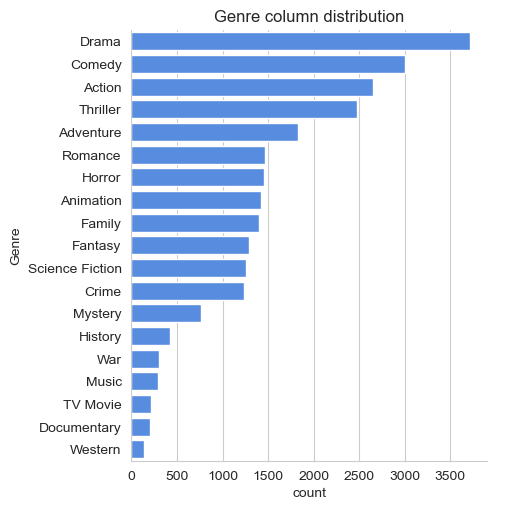

In [125]:
sns.catplot(y = 'Genre', data = df, kind = 'count', 
            order = df['Genre'].value_counts().index,
            color = '#4287f5')
plt.title('Genre column distribution')
plt.show()

# Which has highest votes in vote avg column?

In [132]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,1970,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,1970,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,1970,The Batman,3827.658,1151,popular,Crime
4,1970,The Batman,3827.658,1151,popular,Mystery


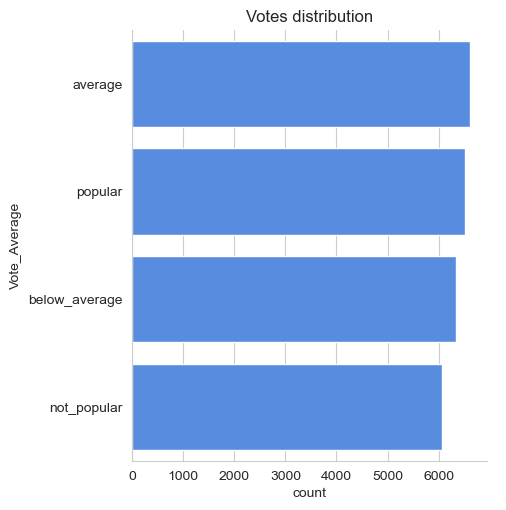

In [138]:
sns.catplot(y = 'Vote_Average', data = df, kind = 'count', 
            order = df['Vote_Average'].value_counts().index,
            color = '#4287f5')
plt.title('Votes distribution')
plt.show()

# What movie got the highest popularity? what's its genre?



In [141]:
df[df['Popularity'] == df['Popularity'].max()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,1970,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,1970,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,1970,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction


# What movie got the lowest popularity? what's its genre?


In [146]:
df[df['Popularity'] == df['Popularity'].min()]

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
25546,1970,The United States vs. Billie Holiday,13.354,152,average,Music
25547,1970,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,1970,The United States vs. Billie Holiday,13.354,152,average,History
25549,1970,Threads,13.354,186,popular,War
25550,1970,Threads,13.354,186,popular,Drama
25551,1970,Threads,13.354,186,popular,Science Fiction


# Which year has the most filmmed movies?

In [155]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [159]:
df['Release_Year'] = df['Release_Date'].dt.year

In [167]:
df[['Release_Date', 'Release_Year']].head()

,Release_Date,Release_Year
0,1970-01-01 00:00:00.000001970,1970
1,1970-01-01 00:00:00.000001970,1970
2,1970-01-01 00:00:00.000001970,1970
3,1970-01-01 00:00:00.000001970,1970
4,1970-01-01 00:00:00.000001970,1970


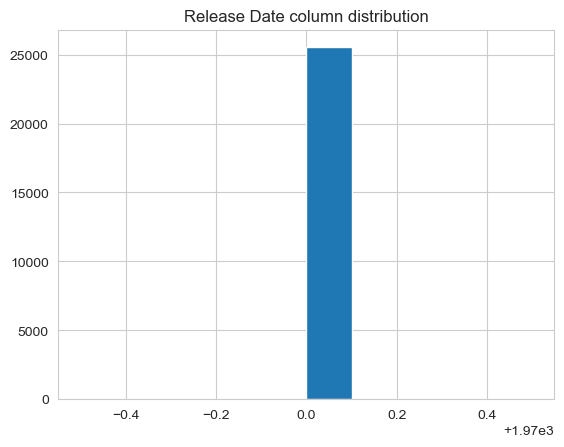

In [151]:
df['Release_Date'].hist()
plt.title('Release Date column distribution')
plt.show()

In [163]:
df['Release_Year'].value_counts().idxmax()

1970

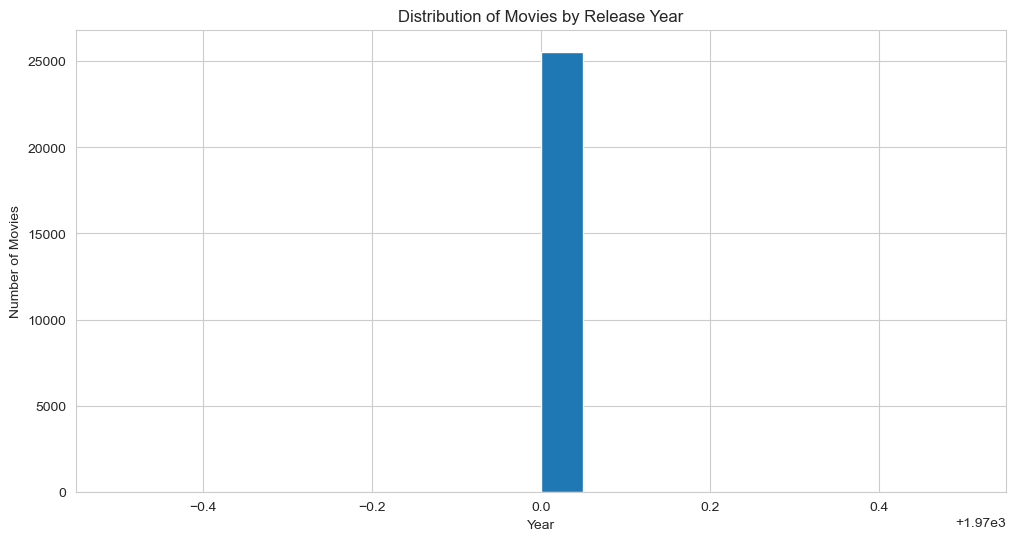

In [169]:
plt.figure(figsize=(12,6))
plt.hist(df['Release_Year'], bins=20)
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Distribution of Movies by Release Year')
plt.show()

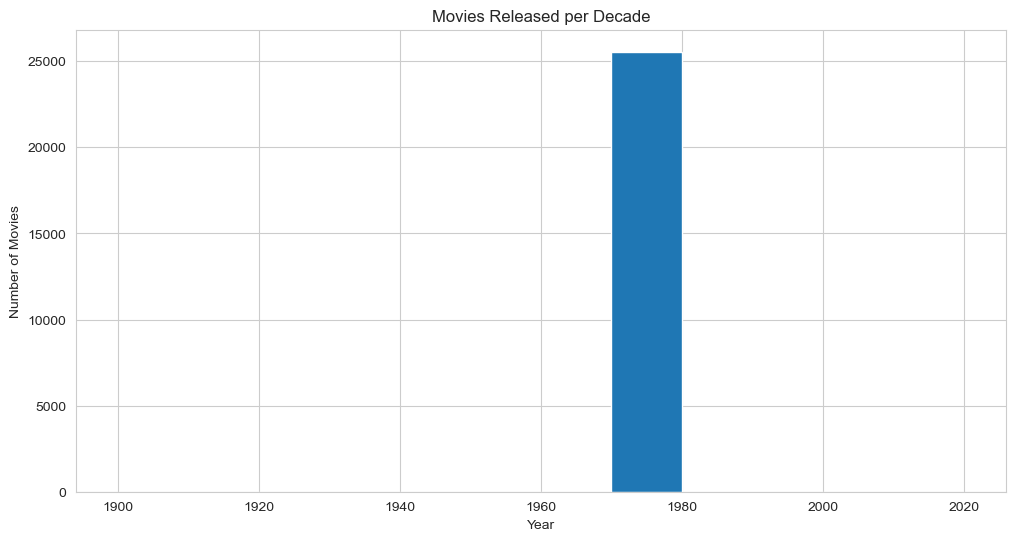

In [171]:
plt.figure(figsize=(12,6))
plt.hist(df['Release_Year'], bins=range(1900, 2030, 10))
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Movies Released per Decade')
plt.show()

# Conclusion


Q1: What is the most frequent genre in the dataset?

Drama genre is the most frequent genre in our dataset and has appeared more than 14% of the times among 19 other genres.

Q2: What genres has highest votes?

we have 25.5% of our dataset with popular vote (6520 rows). Drama again gets the highest popularity among fans by being having more than 18.5% movies

Q3: What movie got the highest popularity? what's its genre?

Spider-Man: No Way Home has the highest popularity rate in our dataset and it has genres of Action, Adventure and Sience Fiction.

Q4: What movie got the lowest popularity? what's its genre?

The united states, thread has the highest lowest rate in our dataset and it has genres o music, drama, 'war', 'sci-fi and historic

Q5: Which year has the most filmmed movies?

year 1970 has the highest filmming rate in our dataset.